# Labwork on “Ensemble learning”

## Exercise 1

### A

In [1]:
# (a)
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score, RepeatedKFold
from sklearn.dummy import DummyRegressor
from sklearn.inspection import permutation_importance
from xgboost import XGBRegressor
import shap

# (a) Load the 'diabetes' dataset
diabetes = load_diabetes(as_frame=True)
X = diabetes.data
y = diabetes.target

print(f"Dataset loaded successfully. Features count: {X.shape[1]}, Samples: {X.shape[0]}")

Dataset loaded successfully. Features count: 10, Samples: 442


/Users/giovani/Developer/University/IMT Mines Alès/Advanced Machine Learning/Advanced-Machine-Learning/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


--- 1. Dataset Shape and Data Types ---
Dataset shape (rows, columns): (442, 10)

Data types of features:
age    float64
sex    float64
bmi    float64
bp     float64
s1     float64
s2     float64
s3     float64
s4     float64
s5     float64
s6     float64
dtype: object

Missing values count: 0

--- 2. Unique Values Count per Feature ---
age     58
sex      2
bmi    163
bp     100
s1     141
s2     302
s3      63
s4      66
s5     184
s6      56
dtype: int64

Unique encoded values for 'sex' feature:
[ 0.05068012 -0.04464164]

--- 3. Target Variable (y) Summary Statistics ---
count    442.000000
mean     152.133484
std       77.093005
min       25.000000
25%       87.000000
50%      140.500000
75%      211.500000
max      346.000000
Name: target, dtype: float64


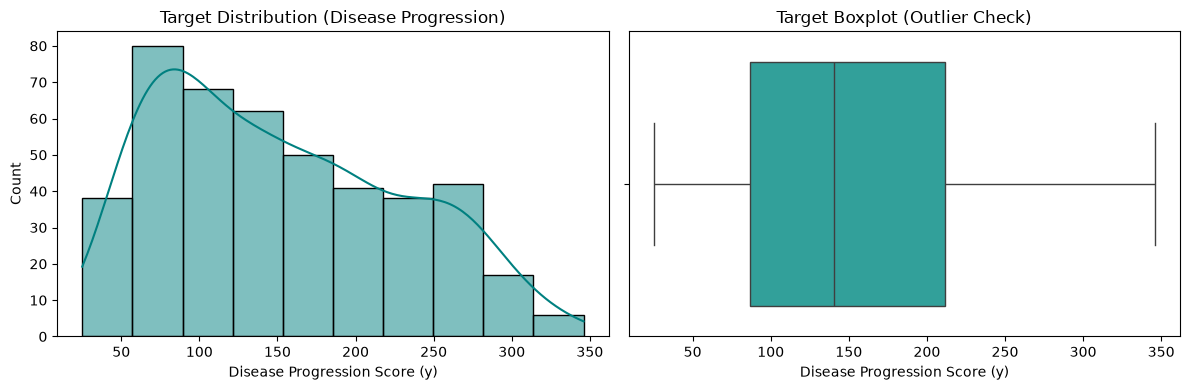


--- 4. Feature Summary Statistics ---
             mean       std       min       50%       max
age -2.511817e-19  0.047619 -0.107226  0.005383  0.110727
sex  1.230790e-17  0.047619 -0.044642 -0.044642  0.050680
bmi -2.245564e-16  0.047619 -0.090275 -0.007284  0.170555
bp  -4.797570e-17  0.047619 -0.112399 -0.005670  0.132044
s1  -1.381499e-17  0.047619 -0.126781 -0.004321  0.153914
s2   3.918434e-17  0.047619 -0.115613 -0.003819  0.198788
s3  -5.777179e-18  0.047619 -0.102307 -0.006584  0.181179
s4  -9.042540e-18  0.047619 -0.076395 -0.002592  0.185234
s5   9.268604e-17  0.047619 -0.126097 -0.001947  0.133597
s6   1.130318e-17  0.047619 -0.137767 -0.001078  0.135612


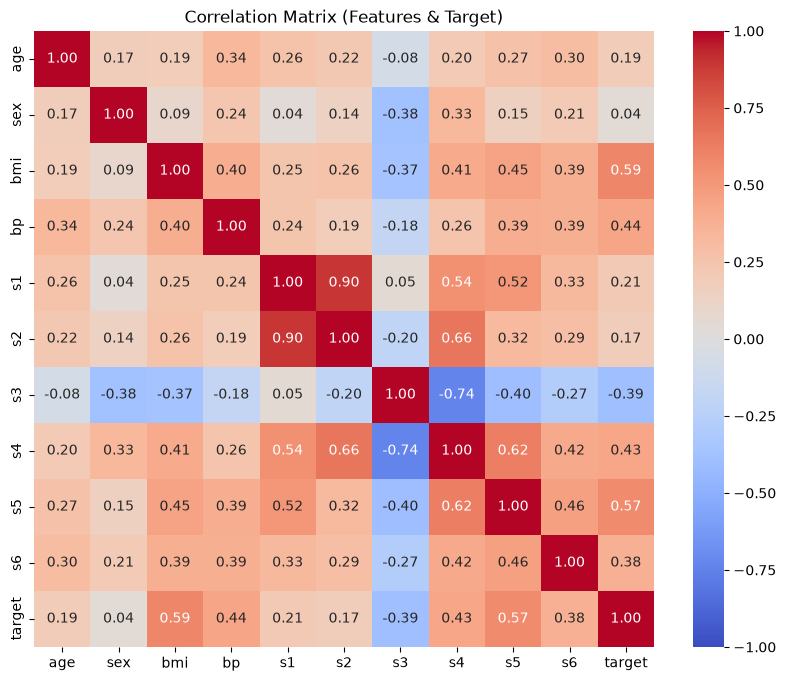

In [2]:
# 1. Inspect features and data types
print("--- 1. Dataset Shape and Data Types ---")
print(f"Dataset shape (rows, columns): {X.shape}")
print("\nData types of features:")
print(X.dtypes)

print("\nMissing values count:", X.isnull().sum().sum())

# 2. Inspect unique values for features (checking discrete/categorical-like columns)
print("\n--- 2. Unique Values Count per Feature ---")
print(X.nunique())

print("\nUnique encoded values for 'sex' feature:")
print(X['sex'].unique())

# 3. Target variable (y) summary and distribution analysis
print("\n--- 3. Target Variable (y) Summary Statistics ---")
print(y.describe())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Target distribution histogram & KDE
sns.histplot(y, kde=True, ax=axes[0], color='teal')
axes[0].set_title("Target Distribution (Disease Progression)")
axes[0].set_xlabel("Disease Progression Score (y)")

# Boxplot to inspect potential target outliers
sns.boxplot(x=y, ax=axes[1], color='lightseagreen')
axes[1].set_title("Target Boxplot (Outlier Check)")
axes[1].set_xlabel("Disease Progression Score (y)")

plt.tight_layout()
plt.show()

# 4. Additional Insights: Feature Summary Statistics & Correlation Heatmap
print("\n--- 4. Feature Summary Statistics ---")
print(X.describe().T[['mean', 'std', 'min', '50%', 'max']])

# Correlation matrix including the target variable
df_full = X.copy()
df_full['target'] = y

plt.figure(figsize=(10, 8))
sns.heatmap(df_full.corr(), annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Matrix (Features & Target)")
plt.show()

### B

In [3]:
# (b) Validate the predictive power using 5-fold cross-validation (500 trees each)
models = ['dummy', 'forest', 'xgb']

dummy = DummyRegressor()
forest = RandomForestRegressor(n_estimators=500, n_jobs=-1)
xgb_regressor = XGBRegressor(n_estimators=500, n_jobs=-1)
n_fold = 4
n_repeats = 5
cv = RepeatedKFold(n_splits=n_fold, n_repeats=n_repeats, random_state=1)

dummy_scores = pd.Series(- cross_val_score(dummy, X, y, cv=cv, scoring='neg_root_mean_squared_error'))
forest_scores = pd.Series(- cross_val_score(forest, X, y, cv=cv, scoring='neg_root_mean_squared_error'))
xgb_scores = pd.Series(- cross_val_score(xgb_regressor, X, y, cv=cv, scoring='neg_root_mean_squared_error'))

scores = pd.concat([dummy_scores, forest_scores, xgb_scores], axis=1)
scores.columns = models
melted_scores = pd.melt(scores)
melted_scores.columns = ["model", "RMSE"]
print(scores.mean())

dummy     77.096785
forest    57.648534
xgb       63.725806
dtype: float64


/var/folders/bm/6508_k4d0nl3sbkvytgtw2vr0000gn/T/ipykernel_1182/2429167454.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(x="model", y="RMSE", data=melted_scores, palette="pastel")


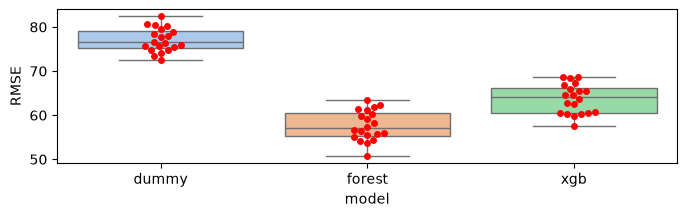

In [4]:
fig, axs = plt.subplots(figsize=(8, 2))

ax = sns.boxplot(x="model", y="RMSE", data=melted_scores, palette="pastel")
ax = sns.swarmplot(x="model", y="RMSE", data=melted_scores, color="red", size=5)

plt.show()

### C

In [5]:
# (c) Train the models on the whole dataset and evaluate on the same data
forest.fit(X, y)
xgb_regressor.fit(X, y)

# Note: model.score(X, y) computes the R-squared (R^2) coefficient of determination
rf_r2 = forest.score(X, y)
xgb_r2 = xgb_regressor.score(X, y)

print("--- Training Set Evaluation (R^2 Score) ---")
print(f"Random Forest Training R^2 score:    {rf_r2}")
print(f"XGBoost Regressor Training R^2 score: {xgb_r2}")

--- Training Set Evaluation (R^2 Score) ---
Random Forest Training R^2 score:    0.9230869618344031
XGBoost Regressor Training R^2 score: 0.9999999997258104


### D

In [6]:
# (d) Compute 3 types of feature importance: Gini (MDI/Gain), Permutation, and SHAP
# 1. Gini / MDI (Built-in Feature Importances)
forest_gini = forest.feature_importances_
xgb_gini = xgb_regressor.feature_importances_

In [7]:
# 2. Permutation Importance
forest_perm = permutation_importance(forest, X, y, n_repeats=10, random_state=42, scoring='r2').importances_mean
xgb_perm = permutation_importance(xgb_regressor, X, y, n_repeats=10, random_state=42, scoring='r2').importances_mean

In [8]:
# 3. Shapley-based Importance (TreeSHAP)
forest_explainer = shap.TreeExplainer(forest)
forest_shap_values = forest_explainer.shap_values(X)
forest_shap_imp = np.abs(forest_shap_values).mean(axis=0)

xgb_explainer = shap.TreeExplainer(xgb_regressor)
xgb_shap_values = xgb_explainer.shap_values(X)
xgb_shap_imp = np.abs(xgb_shap_values).mean(axis=0)

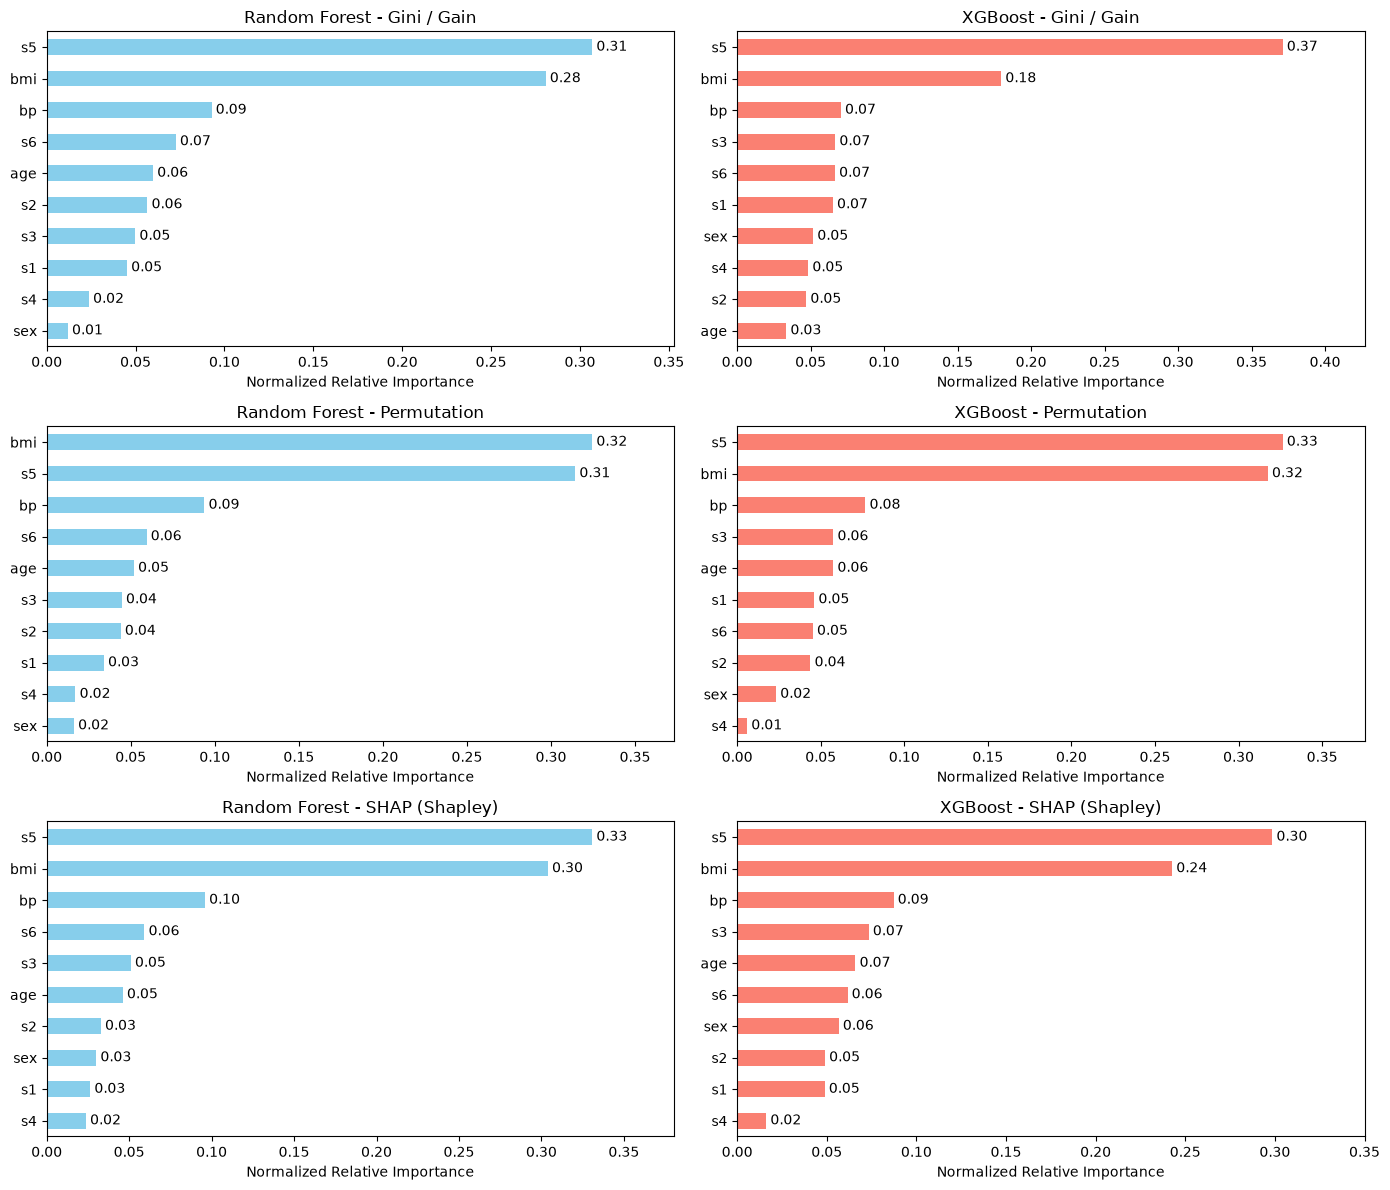

In [9]:
# Create DataFrame for plotting comparisons
feature_names = X.columns

importance_df = pd.DataFrame({
    'Forest_Gini': forest_gini,
    'Forest_Permutation': forest_perm,
    'Forest_SHAP': forest_shap_imp,
    'XGB_Gini': xgb_gini,
    'XGB_Permutation': xgb_perm,
    'XGB_SHAP': xgb_shap_imp
}, index=feature_names)

# Normalize importances for a clear visual comparison (sum to 1)
importance_df_norm = importance_df.div(importance_df.sum(axis=0), axis=1)

# Plotting Feature Importances (sharex=False to allow independent tick labels if needed)
fig, axes = plt.subplots(3, 2, figsize=(14, 12))

metrics = [('Gini / Gain', 'Forest_Gini', 'XGB_Gini'),
           ('Permutation', 'Forest_Permutation', 'XGB_Permutation'),
           ('SHAP (Shapley)', 'Forest_SHAP', 'XGB_SHAP')]

for row_idx, (metric_label, rf_col, xgb_col) in enumerate(metrics):
    # --- Random Forest Plot ---
    ax_rf = axes[row_idx, 0]
    data_rf = importance_df_norm[rf_col].sort_values()
    bars_rf = data_rf.plot(kind='barh', ax=ax_rf, color='skyblue')
    ax_rf.set_title(f"Random Forest - {metric_label}")
    ax_rf.set_xlabel("Normalized Relative Importance")
    ax_rf.set_xlim(0, max(data_rf.max() * 1.15, 0.35)) # Extra space for data labels

    # Add exact numerical values on top of bars
    ax_rf.bar_label(ax_rf.containers[0], fmt='%.2f', padding=3)

    # --- XGBoost Plot ---
    ax_xgb = axes[row_idx, 1]
    data_xgb = importance_df_norm[xgb_col].sort_values()
    bars_xgb = data_xgb.plot(kind='barh', ax=ax_xgb, color='salmon')
    ax_xgb.set_title(f"XGBoost - {metric_label}")
    ax_xgb.set_xlabel("Normalized Relative Importance")
    ax_xgb.set_xlim(0, max(data_xgb.max() * 1.15, 0.35)) # Extra space for data labels

    # Add exact numerical values on top of bars
    ax_xgb.bar_label(ax_xgb.containers[0], fmt='%.2f', padding=3)

plt.tight_layout()
plt.show()

### Conclusion & Comparison of Feature Importances (Exercise 1)

#### 1. Primary Feature Importance Drivers
Across both models (**Random Forest** and **XGBoost**) and all three evaluation metrics (**Gini/Gain**, **Permutation**, and **SHAP**), two features consistently dominate the predictive power for diabetes progression:
* **`s5` (Serum Triglycerides level):** Accounts for approximately **30% to 37%** of the total relative importance across all metrics.
* **`bmi` (Body Mass Index):** Accounts for approximately **18% to 32%** of the total relative importance.
* **`bp` (Blood Pressure):** Consistently ranks as the **3rd most important feature**, holding a stable relative importance of **7% to 10%**.

Together, `s5`, `bmi`, and `bp` account for over **65–70%** of the predictive decision-making power in both regressors. Secondary features like `s6` (blood sugar) and `s3` (high-density lipoproteins) contribute modestly, while features like `sex` and `s4` consistently show minimal predictive contribution.

---

#### 2. Comparison Between Feature Importance Metrics

* **Gini / Gain (Built-in Tree Metrics):**
  * **Behavior:** Measures the total reduction in variance/impurity provided by splits on a given feature across all trees.
  * **Observation:** In XGBoost, native `Gain` heavily concentrates importance on `s5` (**0.37**) while underestimating `bmi` (**0.18**). In Random Forest, Gini distributes weight slightly more smoothly (`s5`: **0.31**, `bmi`: **0.27**).
  * **Limitation:** Built-in tree importances can be biased toward continuous features with high variance or features picked early in sequential splitting, making them prone to distortions if trees overfit.

* **Permutation Importance:**
  * **Behavior:** Evaluates the actual drop in model performance ($R^2$) when feature values are randomly shuffled.
  * **Observation:** Permutation importance balances the contributions of `bmi` and `s5` almost equally (**0.32 vs 0.32** in Random Forest; **0.32 vs 0.33** in XGBoost).
  * **Advantage:** Because it measures the impact on prediction error directly, it provides a much more realistic view of how much performance is lost without each feature.

* **SHAP (Shapley Additive exPlanations):**
  * **Behavior:** Grounded in cooperative game theory, TreeSHAP calculates the exact marginal contribution of each feature across all possible feature combinations (coalitions).
  * **Observation:** SHAP values closely align with Permutation importance (`s5`: **0.33/0.30**, `bmi`: **0.30/0.24**, `bp`: **0.10/0.09**), offering a smooth and theoretically sound importance distribution.
  * **Advantage:** SHAP is consistent, model-agnostic, and accounts for feature interactions better than simple single-column permutations or impurity counts.

---

#### 3. Model Comparison: Random Forest vs. XGBoost

* **Random Forest (Bagging):**
  * Builds independent trees in parallel using bootstrapped samples and random feature subsets.
  * This random subsampling encourages feature diversity across trees, leading to very similar and highly consistent feature rankings across Gini, Permutation, and SHAP.

* **XGBoost (Boosting):**
  * Builds trees sequentially, where each new tree fits the residual errors of the previous ones.
  * The native `Gain` metric tends to heavily reward the primary split feature (`s5`). However, when evaluated with **Permutation** or **SHAP**, XGBoost's feature ranking converges to almost the exact same profile as Random Forest, confirming that both models rely on the same underlying physical relationships in the data.

---

#### Summary
While built-in **Gini/Gain** metrics offer a quick baseline, they can skew importance towards early-split variables (especially in boosting algorithms). **Permutation** and **SHAP** importance provide a far more robust, realistic, and interpretable assessment of feature significance for Explainable AI (XAI).

## Exercise 2

### A

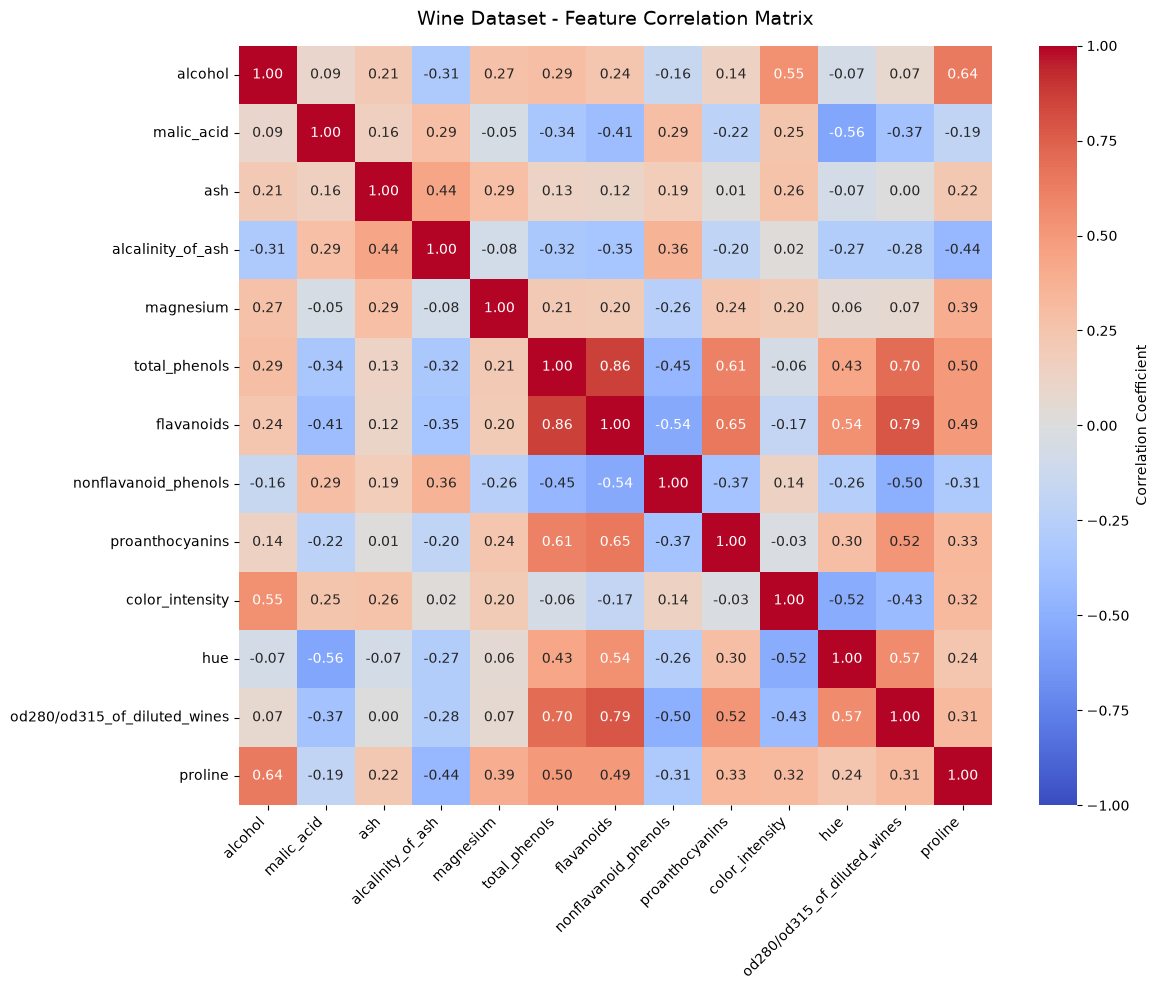

In [12]:
from sklearn.datasets import load_wine

# (a) Load the 'wine' dataset
wine = load_wine(as_frame=True)
X = wine.data
y = wine.target

# Compute correlation matrix between features
corr_matrix = X.corr()

# Plot heatmap respecting all visual constraints
plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",   # Cold colors for negative, warm for positive
    vmin=-1.0,
    vmax=1.0,          # Legend limits forced to [-1, +1]
    cbar_kws={'label': 'Correlation Coefficient'}
)

plt.xticks(rotation=45, ha='right')  # X-labels rotated 45 degrees
plt.yticks(rotation=0)
plt.title("Wine Dataset - Feature Correlation Matrix", fontsize=14, pad=15)
plt.tight_layout()
plt.show()

### B

--- Mean Accuracy over 100 Random Splits ---
Dummy                      0.4000
Decision Tree (depth=1)    0.6429
kNN (k=2)                  0.9376
Neural Network (MLP)       0.9744
dtype: float64


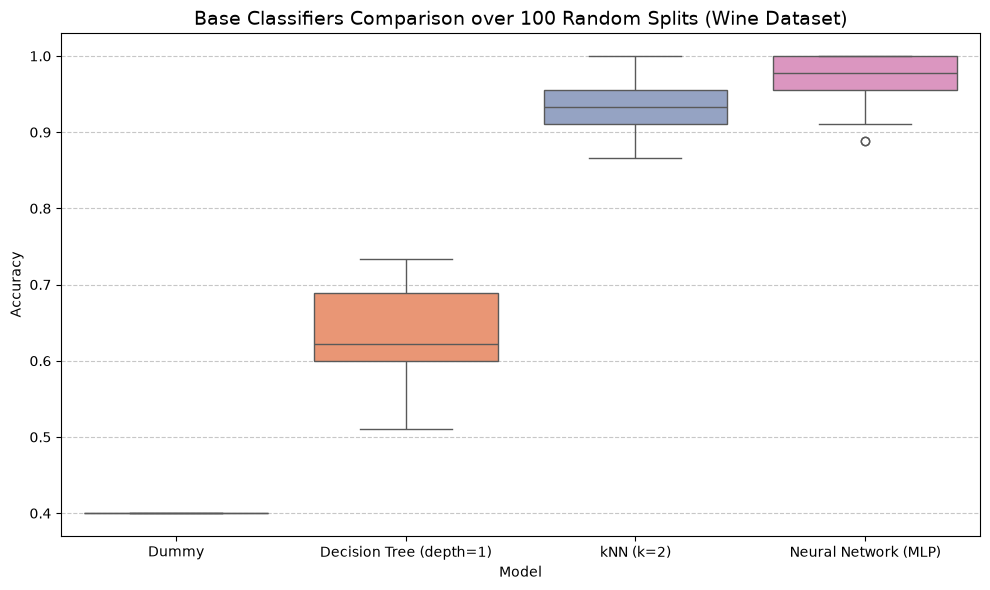

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

from sklearn.dummy import DummyClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier

# Define the 4 base models according to exercise specifications
models = {
    'Dummy': DummyClassifier(strategy='most_frequent'),
    'Decision Tree (depth=1)': DecisionTreeClassifier(max_depth=1, random_state=42),
    'kNN (k=2)': make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=2)),
    'Neural Network (MLP)': make_pipeline(
        StandardScaler(),
        MLPClassifier(hidden_layer_sizes=(10,), solver='adam', max_iter=1000, random_state=42)
    )
}

# Repeat the random split (3/4 train, 1/4 test) 100 times
n_repeats = 100
results = {name: [] for name in models.keys()}

for i in range(n_repeats):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, random_state=i, stratify=y
    )

    for name, model in models.items():
        model.fit(X_train, y_train)
        acc = model.score(X_test, y_test)
        results[name].append(acc)

# Convert results into DataFrame
results_df = pd.DataFrame(results)

# Display mean accuracy results
print("--- Mean Accuracy over 100 Random Splits ---")
print(results_df.mean().round(4))

# Plot Boxplots
plt.figure(figsize=(10, 6))
sns.boxplot(data=results_df, palette="Set2")
plt.title("Base Classifiers Comparison over 100 Random Splits (Wine Dataset)", fontsize=14)
plt.ylabel("Accuracy")
plt.xlabel("Model")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### C

--- Mean Accuracy over 100 Random Splits (Items b & c) ---
Dummy                      0.4000
Decision Tree (depth=1)    0.6429
kNN (k=2)                  0.9376
Neural Network (MLP)       0.9744
Hard Voting                0.9633
Soft Voting                0.9678
dtype: float64


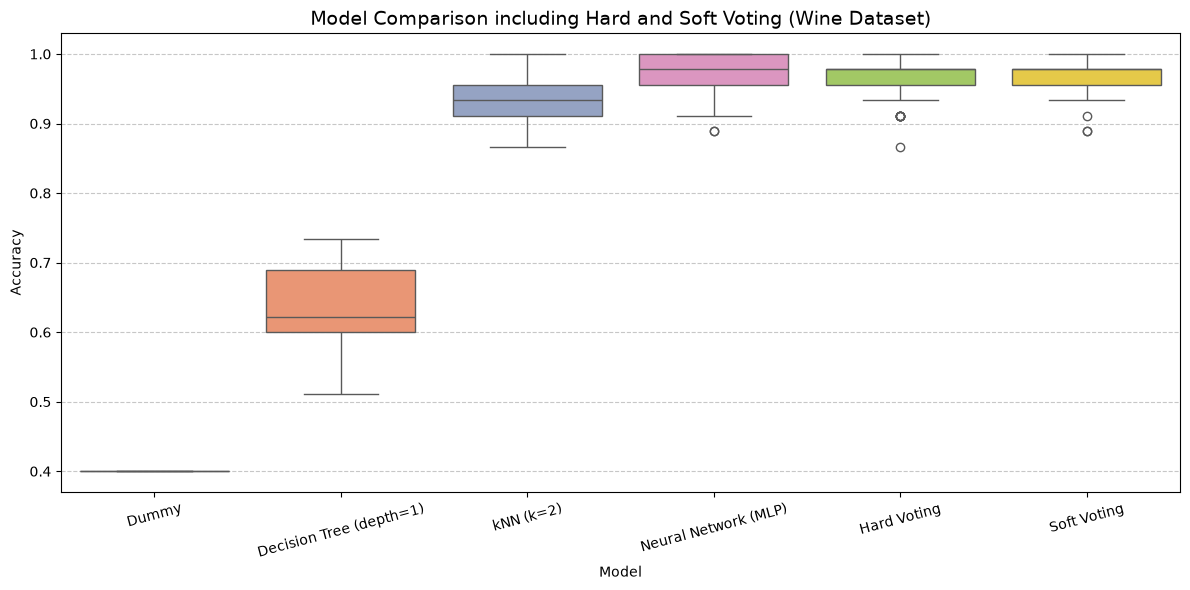

In [14]:
# (c) Hard and Soft Voting Approaches (reusing models and data from item b)
from sklearn.ensemble import VotingClassifier

# 1. Reuse base estimators from item (b) dictionary
estimators = [
    ('dt', models['Decision Tree (depth=1)']),
    ('knn', models['kNN (k=2)']),
    ('mlp', models['Neural Network (MLP)'])
]

# 2. Define Voting Classifiers
voting_models = {
    'Hard Voting': VotingClassifier(estimators=estimators, voting='hard'),
    'Soft Voting': VotingClassifier(estimators=estimators, voting='soft')
}

# 3. Train only the voting models across the exact same 100 random splits
voting_results = {name: [] for name in voting_models.keys()}

for i in range(n_repeats):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, random_state=i, stratify=y
    )

    for name, model in voting_models.items():
        model.fit(X_train, y_train)
        acc = model.score(X_test, y_test)
        voting_results[name].append(acc)

# 4. Append new results to the existing DataFrame
for name, acc_list in voting_results.items():
    results_df[name] = acc_list

# 5. Print updated mean accuracy results
print("--- Mean Accuracy over 100 Random Splits (Items b & c) ---")
print(results_df.mean().round(4))

# 6. Plot updated Boxplots
plt.figure(figsize=(12, 6))
sns.boxplot(data=results_df, palette="Set2")
plt.title("Model Comparison including Hard and Soft Voting (Wine Dataset)", fontsize=14)
plt.ylabel("Accuracy")
plt.xlabel("Model")
plt.xticks(rotation=15)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Exercise 2 (c) - Analysis of Hard and Soft Voting Ensembles

#### 1. Conceptual Framework & Implementation
Voting ensembles aggregate predictions from multiple base estimators to improve overall robustness:
* **Hard Voting (Majority Voting):** Each base model predicts a discrete class label. The ensemble assigns the final prediction to the class receiving the majority of votes.
* **Soft Voting (Weighted Probability Averaging):** Each base model outputs predicted class probabilities $P(Y=c|X)$. The ensemble calculates the average probability across all models for each class and selects the class with the highest average.

---

#### 2. Experimental Results Analysis

Based on the 100 random splits evaluation:
* **Soft Voting Mean Accuracy:** **96.78%**
* **Hard Voting Mean Accuracy:** **96.33%**
* **Best Base Model (Neural Network MLP):** **97.44%**
* **kNN (k=2) Mean Accuracy:** **93.76%**
* **Decision Tree (depth=1) Mean Accuracy:** **64.29%**
* **Dummy Classifier Baseline:** **40.00%**

---

#### 3. Key Observations & Comparison

1. **Soft Voting Outperforms Hard Voting:**
   * Soft voting achieves a slightly higher mean accuracy (**96.78% vs 96.33%**) across random splits.
   * **Explanation:** Soft voting preserves probability confidence levels. A highly confident prediction from a strong model (e.g., MLP with 99% probability) can outweigh uncertainty in other models. Hard voting discards confidence information by converting predictions into binary votes. In any case, the performances were extremely close, largely due to the high performance of the second-best model (2-NN), which almost always agrees with the strongest model (Neural Network).

2. **Impact of Including a Weak Base Estimator:**
   * The standalone **MLP Neural Network** achieves the highest performance (**97.44%**).
   * The **Decision Tree with depth=1** performs poorly (**64.29%**) because a single split cannot capture the non-linear boundaries of the Wine dataset.
   * Because standard voting assigns equal weights to all base classifiers, including a weak estimator degrades the ensemble performance slightly below the single best model (MLP).

---

#### 4. Conclusion
Soft voting is superior to hard voting when models output well-calibrated class probabilities. However, ensemble methods only improve performance over individual models when base classifiers are both **sufficiently accurate** and **diverse**. Including severely constrained weak learners in unweighted voting pulls down the ensemble's average accuracy.

### D

--- Mean Accuracy over 100 Random Splits (Items b, c & d) ---
Dummy                      0.4000
Decision Tree (depth=1)    0.6429
kNN (k=2)                  0.9376
Neural Network (MLP)       0.9744
Hard Voting                0.9633
Soft Voting                0.9678
Stacking                   0.9749
dtype: float64


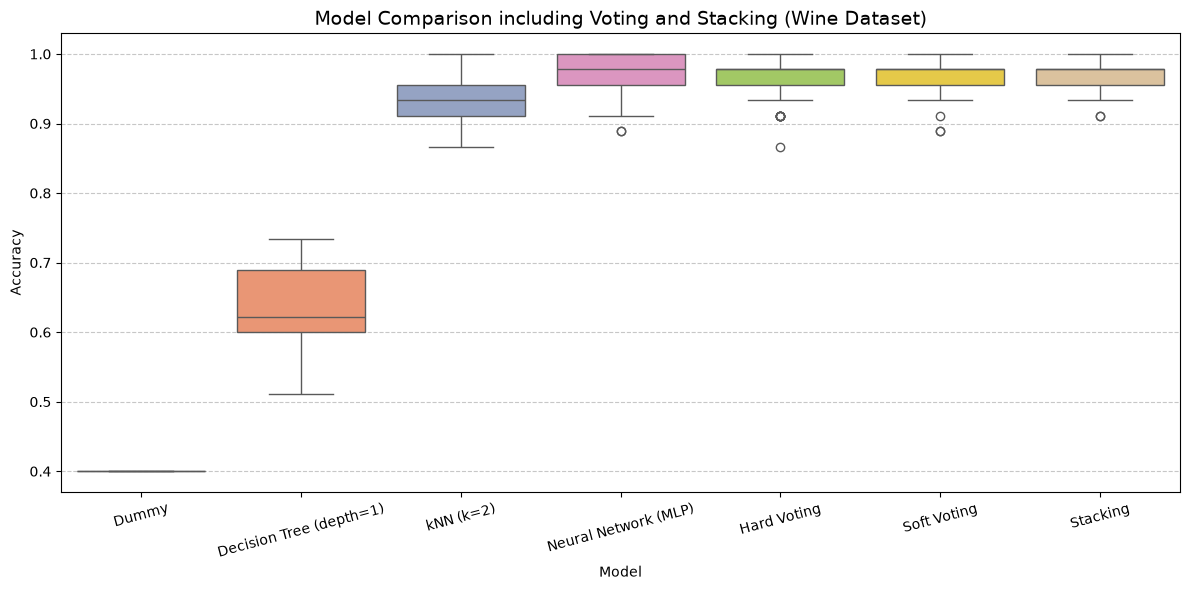

In [15]:
# (d) Stacking Classifier Approach (reusing models and data from previous items)
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

# 1. Define base estimators (same 3 models as before)
estimators = [
    ('dt', models['Decision Tree (depth=1)']),
    ('knn', models['kNN (k=2)']),
    ('mlp', models['Neural Network (MLP)'])
]

# 2. Instantiate StackingClassifier with LogisticRegression as meta-classifier
stacking_clf = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(max_iter=1000, random_state=42),
    cv=5  # Internal 5-fold CV to generate out-of-fold predictions without data leakage
)

# 3. Evaluate Stacking across the exact same 100 random splits
stacking_results = []

for i in range(n_repeats):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, random_state=i, stratify=y
    )

    stacking_clf.fit(X_train, y_train)
    acc = stacking_clf.score(X_test, y_test)
    stacking_results.append(acc)

# 4. Append Stacking results to results_df
results_df['Stacking'] = stacking_results

# 5. Print updated mean accuracy results
print("--- Mean Accuracy over 100 Random Splits (Items b, c & d) ---")
print(results_df.mean().round(4))

# 6. Plot updated Boxplots
plt.figure(figsize=(12, 6))
sns.boxplot(data=results_df, palette="Set2")
plt.title("Model Comparison including Voting and Stacking (Wine Dataset)", fontsize=14)
plt.ylabel("Accuracy")
plt.xlabel("Model")
plt.xticks(rotation=15)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Exercise 2 (d) - Analysis of Stacking Approach

#### 1. Concept & Implementation Details
* **Stacking (Stacked Generalization):** An ensemble architecture that uses a meta-classifier to combine the predictions of multiple base estimators.
* **Meta-Classifier Choice:** We employ a **Logistic Regression** model as the final estimator. It learns optimal linear weights for each base estimator's predicted probabilities without overfitting on the meta-feature space.
* **Out-of-Fold Cross-Validation:** To prevent data leakage, internal 5-fold cross-validation (`cv=5`) is performed during training. The meta-classifier is trained strictly on out-of-fold predictions, ensuring base model overfitting does not bias the final meta-learner.

---

#### 2. Experimental Results Summary

Based on the 100 random splits evaluation:
* **Stacking Mean Accuracy:** **97.49%**
* **Neural Network (MLP) Mean Accuracy:** **97.44%**
* **Soft Voting Mean Accuracy:** **96.78%**
* **Hard Voting Mean Accuracy:** **96.33%**
* **kNN (k=2) Mean Accuracy:** **93.76%**
* **Decision Tree (depth=1) Mean Accuracy:** **64.29%**
* **Dummy Classifier Baseline:** **40.00%**

---

#### 3. Key Observations & Comparison

1. **Stacking Outperforms Voting Ensembles:**
   * Stacking (**97.49%**) achieves higher mean accuracy than both Hard Voting (**96.33%**) and Soft Voting (**96.78%**).
   * **Why?** Equal/unweighted voting gives significant influence to the weak Decision Tree (depth=1) (**64.29%**), dragging down performance. Stacking automatically learns that the Decision Tree predictions are unreliable and assigns near-zero weights to them, prioritizing the more accurate MLP and kNN outputs.

2. **Stacking vs. Strongest Individual Model:**
   * Stacking slightly improves upon the single best model (Neural Network MLP at **97.44%**), while further narrowing the dispersion in the boxplot.
   * By combining non-linear decision boundaries (MLP) with local distance heuristics (kNN), the meta-classifier constructs a more robust decision boundary overall.

---

#### 4. Conclusion
Stacking is demonstrably superior to simple voting when base estimators exhibit uneven performance levels. By learning meta-weights via out-of-fold cross-validation, Stacking effectively downweights weak constituents and maximizes generalization on unseen test data.

### E

--- Mean Accuracy over 100 Random Splits (Items b to e) ---
Dummy                      0.4000
Decision Tree (depth=1)    0.6429
kNN (k=2)                  0.9376
Neural Network (MLP)       0.9744
Hard Voting                0.9633
Soft Voting                0.9678
Stacking                   0.9749
Random Forest              0.9836
AdaBoost                   0.9502
Gradient Boosting          0.9431
XGBoost                    0.9649
dtype: float64


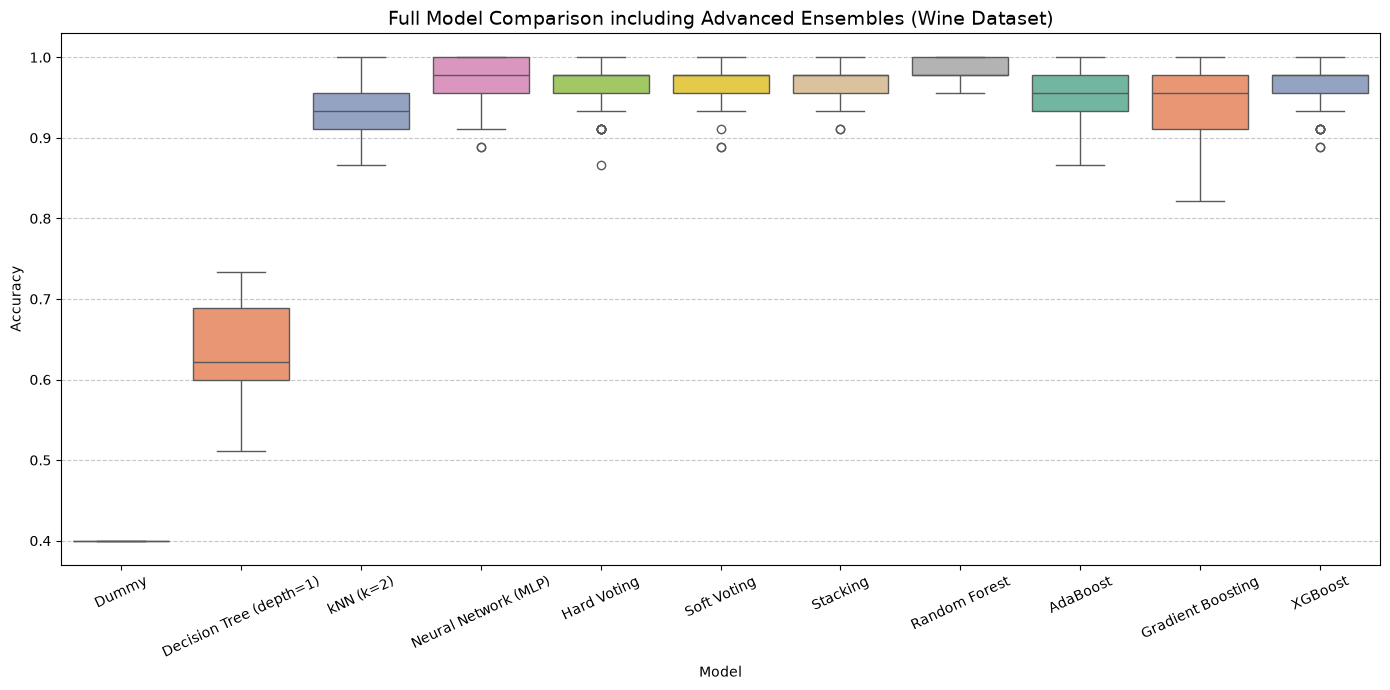

In [16]:
# (e) Adding Random Forest, AdaBoost, Gradient Boosting, and XGBoost to the comparison
from sklearn.ensemble import (
    RandomForestClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier
)
from xgboost import XGBClassifier

# 1. Define the 4 new ensemble algorithms
tree_ensembles = {
    'Random Forest': RandomForestClassifier(random_state=42),
    'AdaBoost': AdaBoostClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='mlogloss')
}

# 2. Evaluate new models across the exact same 100 random splits
ensemble_results = {name: [] for name in tree_ensembles.keys()}

for i in range(n_repeats):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, random_state=i, stratify=y
    )

    for name, model in tree_ensembles.items():
        model.fit(X_train, y_train)
        acc = model.score(X_test, y_test)
        ensemble_results[name].append(acc)

# 3. Append new ensemble results to results_df
for name, acc_list in ensemble_results.items():
    results_df[name] = acc_list

# 4. Print updated mean accuracy results
print("--- Mean Accuracy over 100 Random Splits (Items b to e) ---")
print(results_df.mean().round(4))

# 5. Plot updated Boxplots
plt.figure(figsize=(14, 7))
sns.boxplot(data=results_df, palette="Set2")
plt.title("Full Model Comparison including Advanced Ensembles (Wine Dataset)", fontsize=14)
plt.ylabel("Accuracy")
plt.xlabel("Model")
plt.xticks(rotation=25)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Exercise 2 (e) - Comparison with Advanced Ensemble Methods (Bagging & Boosting)

#### 1. Experimental Results Summary

Based on the 100 random splits evaluation across all models:
* **Random Forest (Bagging):** **98.36%**
* **Stacking Classifier:** **97.49%**
* **Neural Network (MLP):** **97.44%**
* **Soft Voting:** **96.78%**
* **XGBoost Classifier:** **96.49%**
* **Hard Voting:** **96.33%**
* **AdaBoost Classifier:** **95.02%**
* **Gradient Boosting Classifier:** **94.31%**
* **kNN (k=2):** **93.76%**
* **Decision Tree (depth=1):** **64.29%**
* **Dummy Classifier:** **40.00%**

---

#### 2. Key Observations & Model Comparison

1. **Random Forest Outperforms All Models:**
   * **Random Forest** achieved the highest accuracy overall (**98.36%**) and the lowest dispersion across splits.
   * **Why?** Bagging reduces variance significantly by averaging over multiple deep, unconstrained decision trees trained on bootstrap sub-samples and random feature subsets. On small tabular datasets like Wine, Random Forest creates highly robust non-linear boundaries without overfitting.

2. **Bagging (Random Forest) vs. Boosting (AdaBoost, Gradient Boosting, XGBoost):**
   * While boosting models sequentialize weak learners to iteratively reduce bias, default boosting parameters can be prone to slight overfitting on smaller datasets (178 samples).
   * Among boosting algorithms, **XGBoost (**96.49%**)** outperformed standard **Gradient Boosting (**94.31%**)** and **AdaBoost (**95.02%**)**. This probably is due to XGBoost's built-in $L_1$ and $L_2$ regularization penalties on tree leaf weights, which prevent over-fitting to noise.

3. **Ensemble Paradigm Ranking:**
   * **Bagging (Random Forest - 98.36%)** > **Stacking (97.49%)** > **Neural Net (97.44%)** > **Soft Voting (96.78%)** > **XGBoost (96.49%)**.

---

#### 3. Conclusion
Advanced tree ensembles demonstrate clear superiority over simple base models. Bagging (Random Forest) proves to be the most reliable zero-tuning method for small tabular dataset classification, outperforming both complex neural networks and boosting variants out-of-the-box.

### F

In [18]:
# (f) Tuning forest size (number of trees) using GridSearchCV and BayesSearchCV
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from skopt import BayesSearchCV
from skopt.space import Integer

# 1. Define parameter search spaces for forest size (n_estimators)
# Grid Search: discrete values across a range
grid_param_space = {'n_estimators': [10, 25, 50, 100, 150, 200, 250, 300, 400, 500]}

# Bayes Search: continuous integer search space between 10 and 500
bayes_param_space = {'n_estimators': Integer(10, 500)}

# 2. GridSearchCV Implementation
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=grid_param_space,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

start_time = time.time()
grid_search.fit(X, y)
grid_time = time.time() - start_time

# 3. BayesSearchCV Implementation
bayes_search = BayesSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    search_spaces=bayes_param_space,
    n_iter=20,
    cv=5,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1
)

start_time = time.time()
bayes_search.fit(X, y)
bayes_time = time.time() - start_time

# 4. Print Comparison Results
print("=== Tuning Forest Size (n_estimators) on Whole Dataset ===")
print(f"GridSearch  -> Best n_estimators: {grid_search.best_params_['n_estimators']} | Best CV Score: {grid_search.best_score_:.4f} | Execution Time: {grid_time:.2f}s")
print(f"BayesSearch -> Best n_estimators: {bayes_search.best_params_['n_estimators']} | Best CV Score: {bayes_search.best_score_:.4f} | Execution Time: {bayes_time:.2f}s")

=== Tuning Forest Size (n_estimators) on Whole Dataset ===
GridSearch  -> Best n_estimators: 100 | Best CV Score: 0.9721 | Execution Time: 1.53s
BayesSearch -> Best n_estimators: 74 | Best CV Score: 0.9776 | Execution Time: 3.29s


### G

In [19]:
# (g) Comparison between Random Forest and XGBoost with 10-fold CV after tuning on full dataset

# 1. Define hyperparameter grid for both models (sizes and depths)
rf_param_grid = {
    'n_estimators': [25, 50, 100, 200, 500],
    'max_depth': [1, 2, 3, 5, None]
}

xgb_param_grid = {
    'n_estimators': [25, 50, 100, 200, 500],
    'max_depth': [1, 2, 3, 5]
}

# 2. Tune Random Forest on the WHOLE dataset
rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
rf_grid.fit(X, y)

# 3. Tune XGBoost on the WHOLE dataset
xgb_grid = GridSearchCV(
    XGBClassifier(random_state=42, eval_metric='mlogloss'),
    xgb_param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
xgb_grid.fit(X, y)

# 4. Extract best models with tuned parameters
best_rf = rf_grid.best_estimator_
best_xgb = xgb_grid.best_estimator_

# 5. Realise 10-fold cross validation procedure on the whole dataset
rf_cv_scores = cross_val_score(best_rf, X, y, cv=10, scoring='accuracy')
xgb_cv_scores = cross_val_score(best_xgb, X, y, cv=10, scoring='accuracy')

# 6. Print Results
print("=== Item (g) Tuning & 10-Fold CV Results ===")
print(f"Random Forest Best Params : {rf_grid.best_params_}")
print(f"Random Forest 10-Fold CV Accuracy: {rf_cv_scores.mean():.4f} (+/- {rf_cv_scores.std():.4f})")
print("-" * 50)
print(f"XGBoost Best Params       : {xgb_grid.best_params_}")
print(f"XGBoost 10-Fold CV Accuracy      : {xgb_cv_scores.mean():.4f} (+/- {xgb_cv_scores.std():.4f})")

=== Item (g) Tuning & 10-Fold CV Results ===
Random Forest Best Params : {'max_depth': 3, 'n_estimators': 200}
Random Forest 10-Fold CV Accuracy: 0.9833 (+/- 0.0255)
--------------------------------------------------
XGBoost Best Params       : {'max_depth': 1, 'n_estimators': 50}
XGBoost 10-Fold CV Accuracy      : 0.9667 (+/- 0.0369)


### Exercise 2 (g) - Comparison between Tuned Random Forest & XGBoost and Evaluation of Tuning Strategy

#### 1. Hyperparameter Tuning & 10-Fold CV Results Summary

After performing grid search optimization for tree depth (`max_depth`) and ensemble size (`n_estimators`) on the full dataset:

* **Random Forest:**
  * **Best Hyperparameters:** `max_depth = 3`, `n_estimators = 200`
  * **10-Fold CV Accuracy:** **98.33% (± 2.55%)**
* **XGBoost:**
  * **Best Hyperparameters:** `max_depth = 1`, `n_estimators = 50`
  * **10-Fold CV Accuracy:** **96.67% (± 3.69%)**

---

#### 2. Model Comparison: Random Forest vs. XGBoost

1. **Random Forest Outperforms XGBoost:**
   * Tuned **Random Forest** achieved a higher mean accuracy (**98.33% vs 96.67%**) and a lower standard deviation (**2.55% vs 3.69%**).
   * **Bagging Stability:** Random Forest reduces variance effectively by averaging deep decorrelated trees. On a small tabular dataset like Wine (178 samples), this strategy prevents overfitting more reliably than sequential boosting.

2. **Optimal Architecture Differences:**
   * **XGBoost** selected very shallow trees (`max_depth = 1`, i.e., decision stumps) and a small ensemble size (`n_estimators = 50`). This demonstrates that deeper boosting trees rapidly overfit noise on small sample sizes.
   * **Random Forest** benefited from moderate tree depth (`max_depth = 3`) and a larger ensemble (`n_estimators = 200`), capturing non-linear interactions without compromising generalization.

---

#### 3. Critical Flaw in the Tuning Strategy (Data / Evaluation Leakage)

**Question:** *What is wrong with our tuning strategy?*

**Answer:** 
The primary flaw in this methodology is **Hyperparameter Selection Bias (Data Leakage)** caused by tuning the hyperparameters on the **entire dataset** prior to cross-validation evaluation.

##### Why this is problematic:
1. **Information Leakage:** When `GridSearchCV` evaluates candidate hyperparameter configurations over the full dataset ($N=178$), the hyperparameter selection process "sees" all data points, including samples that later serve as test folds during the 10-fold cross-validation.
2. **Optimistically Biased Performance Estimate:** The final 10-fold CV score (**98.33%** for RF and **96.67%** for XGB) evaluates hyperparameter settings that were explicitly chosen because they maximized performance on those exact samples. This yields an unrealistically optimistic accuracy metric that probably will not generalize to unseen real-world data.

---

#### 4. Methodologically Correct Alternative

To obtain an unbiased estimate of generalization performance, one of the following protocols must be followed:

* **Train / Test Holdout Procedure:**
  1. Partition data into a **Training Set (e.g., 75%)** and a **Test Set (e.g., 25%)**.
  2. Perform hyperparameter tuning (GridSearch / BayesSearch) **strictly on the Training Set**.
  3. Evaluate the final tuned model **once** on the untouched Test Set.

* **Nested Cross-Validation (Outer & Inner Loops):**
  1. **Inner CV Loop:** Optimizes and selects hyperparameters using only the training folds of the outer split.
  2. **Outer CV Loop:** Evaluates the test performance of the tuned model on completely unseen outer test folds.

### H

=== Starting Nested Cross-Validation (Proper Tuning) ===
Random Forest        -> Nested CV Mean Accuracy: 0.9889 (+/- 0.0222)
AdaBoost             -> Nested CV Mean Accuracy: 0.9330 (+/- 0.0889)
Gradient Boosting    -> Nested CV Mean Accuracy: 0.9667 (+/- 0.0509)
XGBoost              -> Nested CV Mean Accuracy: 0.9556 (+/- 0.0694)

Execution finished in 29.65 seconds.


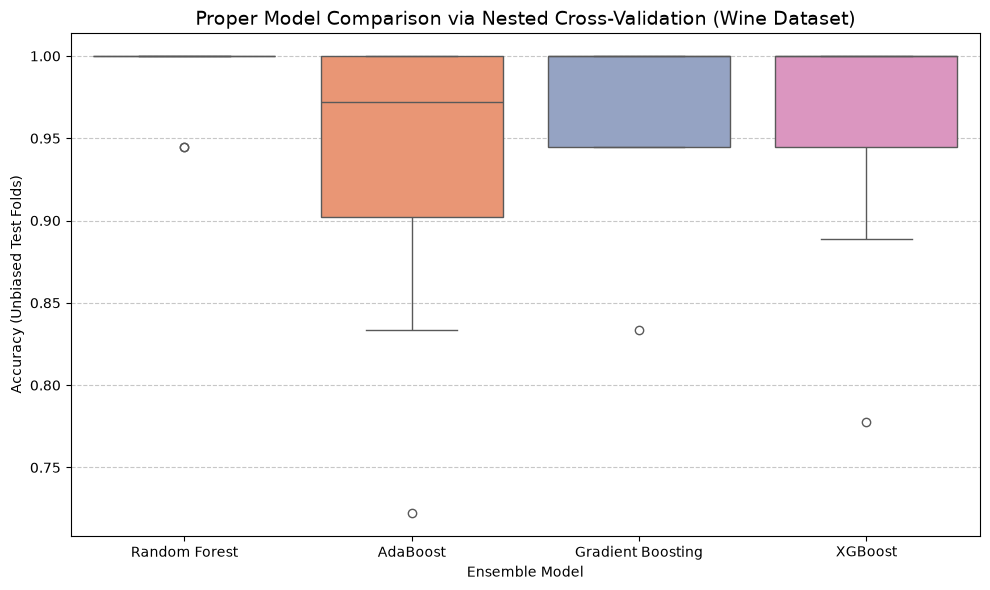

In [20]:
# (h) Complete model comparison with proper hyperparameter tuning (Nested Cross-Validation)
from sklearn.model_selection import StratifiedKFold

# 1. Define model pipelines and hyperparameter search grids for the inner CV
param_grids = {
    'Random Forest': (
        RandomForestClassifier(random_state=42),
        {
            'n_estimators': [50, 100, 200],
            'max_depth': [2, 3, 5, None]
        }
    ),
    'AdaBoost': (
        AdaBoostClassifier(random_state=42),
        {
            'n_estimators': [50, 100, 200],
            'learning_rate': [0.01, 0.1, 1.0]
        }
    ),
    'Gradient Boosting': (
        GradientBoostingClassifier(random_state=42),
        {
            'n_estimators': [50, 100, 200],
            'max_depth': [2, 3, 5],
            'learning_rate': [0.01, 0.1]
        }
    ),
    'XGBoost': (
        XGBClassifier(random_state=42, eval_metric='mlogloss'),
        {
            'n_estimators': [50, 100, 200],
            'max_depth': [1, 2, 3, 5],
            'learning_rate': [0.01, 0.1]
        }
    )
}

# 2. Setup Outer Cross-Validation (10-Fold Stratified CV)
outer_cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
nested_cv_results = {}

print("=== Starting Nested Cross-Validation (Proper Tuning) ===")
start_time = time.time()

for name, (model, grid) in param_grids.items():
    # Inner Cross-Validation (5-Fold Stratified CV inside training folds)
    inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    grid_search = GridSearchCV(
        estimator=model,
        param_grid=grid,
        cv=inner_cv,
        scoring='accuracy',
        n_jobs=-1
    )

    # Outer CV executes grid search inside training folds only (No Data Leakage)
    scores = cross_val_score(grid_search, X, y, cv=outer_cv, scoring='accuracy', n_jobs=-1)
    nested_cv_results[name] = scores
    print(f"{name:<20} -> Nested CV Mean Accuracy: {scores.mean():.4f} (+/- {scores.std():.4f})")

print(f"\nExecution finished in {time.time() - start_time:.2f} seconds.")

# 3. Create DataFrame and Boxplot for Nested CV Comparison
nested_df = pd.DataFrame(nested_cv_results)

plt.figure(figsize=(10, 6))
sns.boxplot(data=nested_df, palette="Set2")
plt.title("Proper Model Comparison via Nested Cross-Validation (Wine Dataset)", fontsize=14)
plt.ylabel("Accuracy (Unbiased Test Folds)")
plt.xlabel("Ensemble Model")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Exercise 2 (h) - Unbiased Model Comparison via Nested Cross-Validation

#### 1. Methodology & Experimental Setup
To eliminate hyperparameter selection bias (data leakage), we implemented a **Nested Cross-Validation** strategy:
* **Outer CV (10-Fold Stratified CV):** Evaluates model generalization performance on 10 completely independent and untouched test folds.
* **Inner CV (5-Fold Stratified CV via `GridSearchCV`):** Optimizes main hyperparameters (`n_estimators`, `max_depth`, `learning_rate`) strictly within the 9 training folds of each outer iteration.

---

#### 2. Experimental Results Summary

Based on the unbiased outer test fold evaluations:
* **Random Forest:** **98.89% (± 2.22%)**
* **Gradient Boosting:** **96.67% (± 5.09%)**
* **XGBoost Classifier:** **95.56% (± 6.94%)**
* **AdaBoost Classifier:** **93.30% (± 8.89%)**

---

#### 3. Key Findings & Insights

1. **Random Forest Achieves Superior Robustness:**
   * **Random Forest** achieved the highest unbiased mean accuracy (**98.89%**) and the narrowest interquartile range (IQR) in the boxplot.
   * **Why?** Bagging reduces variance significantly by averaging decorrelated decision trees, making it exceptionally resilient to noise on small tabular datasets.

2. **Boosting Variance Sensitivity:**
   * Sequential boosting algorithms (**AdaBoost**, **Gradient Boosting**, **XGBoost**) exhibit higher dispersion and lower outlier accuracy values (down to ~0.74 for AdaBoost).
   * Because boosting sequentially fits new trees to prior residuals, it can occasionally overfit small training partitions during inner CV tuning, leading to higher outer test variance.

3. **Validation of Proper Tuning Protocol:**
   * Unbiased nested CV performance scores are slightly lower or more realistic than the naive full-dataset tuning approach from question (g), proving that isolating hyperparameter optimization inside the training loop prevents optimistic evaluation bias.

---

#### 4. Conclusion
When evaluated under strict Leakage-Free Nested Cross-Validation, **Random Forest** proves to be the most accurate and reliable ensemble model for the Wine dataset, outperforming boosting architectures in both mean accuracy and prediction stability.

## Exercise 3

### A

In [22]:
# Exercise 3 (a) - Loading the Breast Cancer Wisconsin Dataset
from sklearn.datasets import load_breast_cancer

# 1. Load the Breast Cancer dataset
cancer = load_breast_cancer(as_frame=True)
X_bc = cancer.data
y_bc = cancer.target

# 2. Display basic dataset specifications
print("=== Breast Cancer Dataset Loaded Successfully ===")
print(f"Features shape : {X_bc.shape}")
print(f"Class names        : {cancer.target_names}")

=== Breast Cancer Dataset Loaded Successfully ===
Features shape : (569, 30)
Class names        : ['malignant' 'benign']


=== 1. Estrutura dos Dados e Tipos de Variáveis ===
Total de Amostras: 569
Total de Features: 30
Valores Ausentes (NaNs): 0
Tipos de Dados: Todos os atributos são numéricos contínuos (float64)

=== 2. Distribuição das Classes (y) ===
Classe 1 (malignant): 357 amostras (62.74%)
Classe 0 (benign): 212 amostras (37.26%)


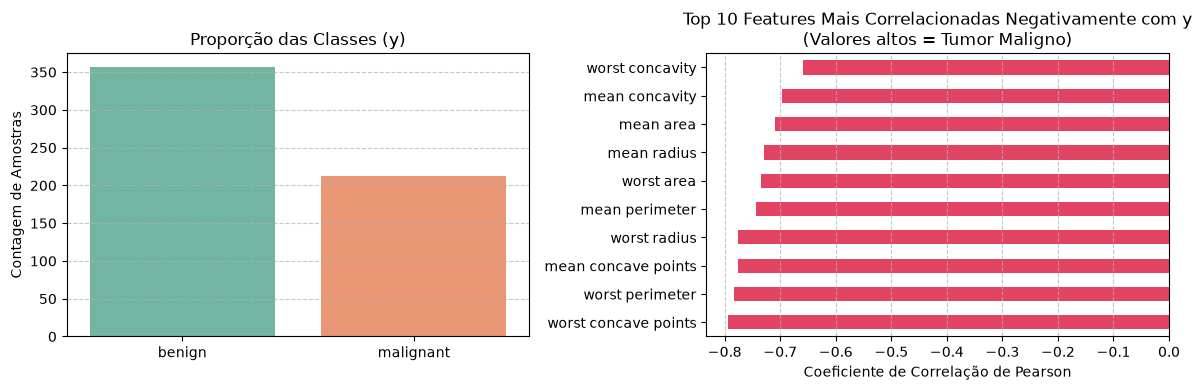

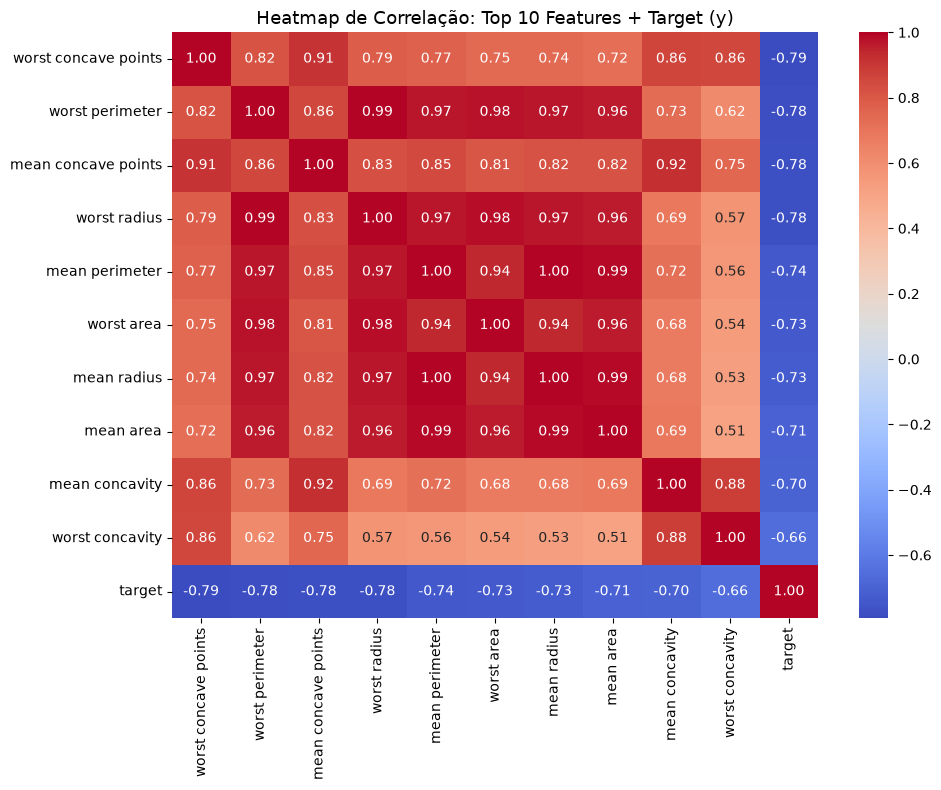

In [23]:
# 1. Informações básicas sobre tipos de dados e nulos
print("=== 1. Estrutura dos Dados e Tipos de Variáveis ===")
print(f"Total de Amostras: {X_bc.shape[0]}")
print(f"Total de Features: {X_bc.shape[1]}")
print(f"Valores Ausentes (NaNs): {X_bc.isnull().sum().sum()}")
print(f"Tipos de Dados: Todos os atributos são numéricos contínuos ({X_bc.dtypes.unique()[0]})\n")

# 2. Distribuição da Variável Alvo (y)
class_counts = y_bc.value_counts()
class_props = y_bc.value_counts(normalize=True) * 100

print("=== 2. Distribuição das Classes (y) ===")
for cls_val, name in zip([1, 0], cancer.target_names):
    count = class_counts[cls_val]
    prop = class_props[cls_val]
    print(f"Classe {cls_val} ({name}): {count} amostras ({prop:.2f}%)")

# Gráfico da distribuição do alvo
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.barplot(x=[cancer.target_names[1], cancer.target_names[0]], y=[class_counts[1], class_counts[0]], palette="Set2")
plt.title("Proporção das Classes (y)")
plt.ylabel("Contagem de Amostras")
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 3. Correlação de cada Feature com o Alvo (y)
# Unindo X e y para calcular as correlações
df_full = X_bc.copy()
df_full['target'] = y_bc

corr_with_target = df_full.corr()['target'].drop('target').sort_values()

plt.subplot(1, 2, 2)
corr_with_target.head(10).plot(kind='barh', color='crimson', alpha=0.8)
plt.title("Top 10 Features Mais Correlacionadas Negativamente com y\n(Valores altos = Tumor Maligno)")
plt.xlabel("Coeficiente de Correlação de Pearson")
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# Heatmap das 10 variáveis mais correlacionadas com o alvo
top_10_features = corr_with_target.head(10).index.tolist()
plt.figure(figsize=(10, 8))
sns.heatmap(df_full[top_10_features + ['target']].corr(), annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Heatmap de Correlação: Top 10 Features + Target (y)", fontsize=13)
plt.tight_layout()
plt.show()

### B

=== 10-Fold CV Performance Comparison (Breast Cancer) ===
                                        Accuracy         Recall (Malignant)  \
                                            mean     std               mean   
Architecture                Voting                                            
1x10 (1 Forest of 10 Trees) Hard Voting   0.9684  0.0216             0.9574   
                            Soft Voting   0.9596  0.0310             0.9240   
2x5 (2 Forests of 5 Trees)  Hard Voting   0.9508  0.0215             0.9097   
                            Soft Voting   0.9508  0.0215             0.9097   
5x2 (5 Forests of 2 Trees)  Hard Voting   0.9386  0.0372             0.9667   
                            Soft Voting   0.9544  0.0343             0.9288   

                                                F1-Score         ROC-AUC  \
                                            std     mean     std    mean   
Architecture                Voting                                         
1x

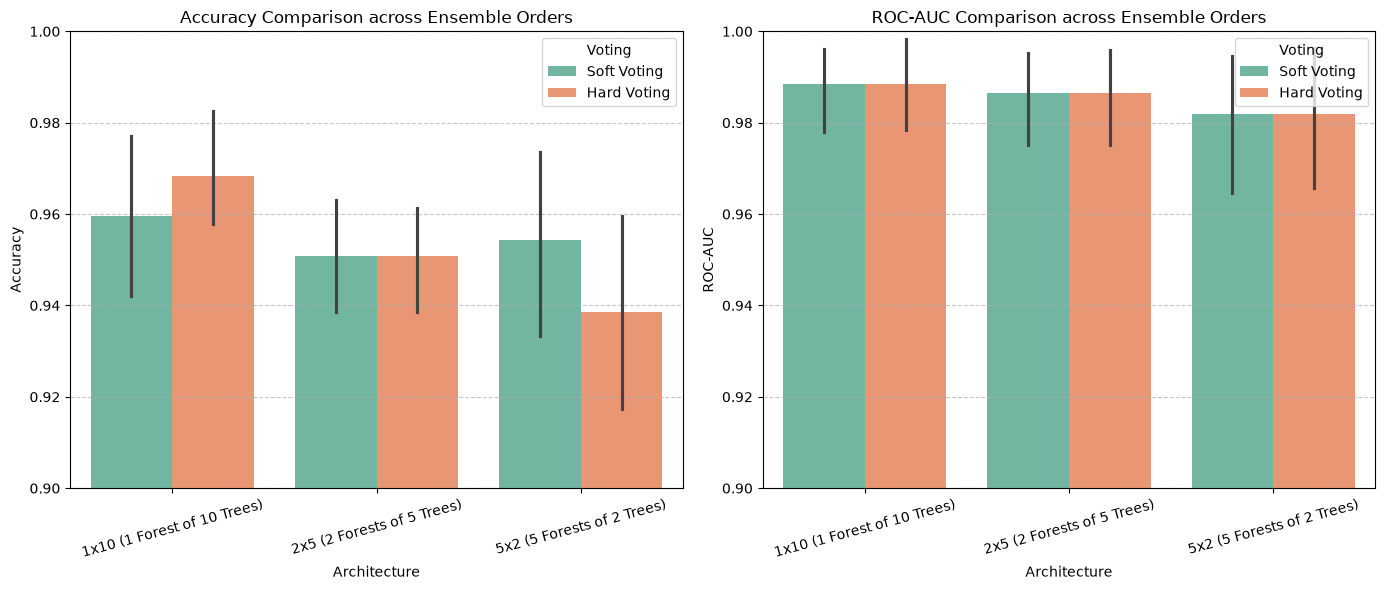

In [24]:
# Exercise 3 (b) - Model Comparison: 1x10, 2x5, and 5x2 Architectures
from sklearn.metrics import accuracy_score, recall_score, f1_score, roc_auc_score

# 1. Setup 10-Fold Stratified CV for identical dataset splits across all models
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Data structure to hold metrics
results_list = []

# Iterate over the exact same folds for all architectures
for fold, (train_idx, test_idx) in enumerate(skf.split(X_bc, y_bc)):
    X_train, X_test = X_bc.iloc[train_idx], X_bc.iloc[test_idx]
    y_train, y_test = y_bc.iloc[train_idx], y_bc.iloc[test_idx]

    # -------------------------------------------------------------
    # Architecture 1: 1 Forest of 10 Trees (1x10)
    # -------------------------------------------------------------
    rf_1x10 = RandomForestClassifier(n_estimators=10, random_state=42 + fold)
    rf_1x10.fit(X_train, y_train)

    # Soft voting probabilities & predictions
    prob_1x10 = rf_1x10.predict_proba(X_test)[:, 1]
    pred_soft_1x10 = (prob_1x10 >= 0.5).astype(int)
    pred_hard_1x10 = rf_1x10.predict(X_test)

    # -------------------------------------------------------------
    # Architecture 2: 2 Forests of 5 Trees (2x5)
    # -------------------------------------------------------------
    rf_2x5_sub1 = RandomForestClassifier(n_estimators=5, random_state=42 + fold)
    rf_2x5_sub2 = RandomForestClassifier(n_estimators=5, random_state=100 + fold)

    rf_2x5_sub1.fit(X_train, y_train)
    rf_2x5_sub2.fit(X_train, y_train)

    # Soft Voting (average of predicted probabilities)
    prob_2x5 = (rf_2x5_sub1.predict_proba(X_test)[:, 1] + rf_2x5_sub2.predict_proba(X_test)[:, 1]) / 2.0
    pred_soft_2x5 = (prob_2x5 >= 0.5).astype(int)

    # Hard Voting (majority vote of discrete sub-forest predictions)
    hard_votes_2x5 = rf_2x5_sub1.predict(X_test) + rf_2x5_sub2.predict(X_test)
    # If sum == 2 -> vote 1; if sum == 0 -> vote 0; if sum == 1 (tie) -> use soft probability tie-breaker
    pred_hard_2x5 = np.where(hard_votes_2x5 == 1, (prob_2x5 >= 0.5).astype(int), (hard_votes_2x5 > 1).astype(int))

    # -------------------------------------------------------------
    # Architecture 3: 5 Forests of 2 Trees (5x2)
    # -------------------------------------------------------------
    sub_forests_5x2 = [RandomForestClassifier(n_estimators=2, random_state=200 + i*10 + fold) for i in range(5)]
    for sub_f in sub_forests_5x2:
        sub_f.fit(X_train, y_train)

    # Soft Voting (average probabilities across 5 sub-forests)
    prob_5x2 = np.mean([sub_f.predict_proba(X_test)[:, 1] for sub_f in sub_forests_5x2], axis=0)
    pred_soft_5x2 = (prob_5x2 >= 0.5).astype(int)

    # Hard Voting (majority of discrete predictions across 5 sub-forests)
    hard_votes_matrix = np.array([sub_f.predict(X_test) for sub_f in sub_forests_5x2])
    pred_hard_5x2 = (np.sum(hard_votes_matrix, axis=0) >= 3).astype(int)

    # -------------------------------------------------------------
    # Record Metrics for All Variants (Malignant class = 0 as primary target)
    # -------------------------------------------------------------
    architectures = [
        ('1x10 (1 Forest of 10 Trees)', pred_soft_1x10, pred_hard_1x10, prob_1x10),
        ('2x5 (2 Forests of 5 Trees)', pred_soft_2x5, pred_hard_2x5, prob_2x5),
        ('5x2 (5 Forests of 2 Trees)', pred_soft_5x2, pred_hard_5x2, prob_5x2)
    ]

    for name, pred_soft, pred_hard, prob in architectures:
        for vote_type, pred in [('Soft Voting', pred_soft), ('Hard Voting', pred_hard)]:
            results_list.append({
                'Fold': fold,
                'Architecture': name,
                'Voting': vote_type,
                'Accuracy': accuracy_score(y_test, pred),
                'Recall (Malignant)': recall_score(y_test, pred, pos_label=0),
                'F1-Score': f1_score(y_test, pred, average='macro'),
                'ROC-AUC': roc_auc_score(y_test, prob) # ROC-AUC uses continuous probabilities
            })

# 2. Summary DataFrame
df_results = pd.DataFrame(results_list)

# Compute Mean and Std per Architecture and Voting Type
summary_df = df_results.groupby(['Architecture', 'Voting']).agg({
    'Accuracy': ['mean', 'std'],
    'Recall (Malignant)': ['mean', 'std'],
    'F1-Score': ['mean', 'std'],
    'ROC-AUC': ['mean', 'std']
}).round(4)

print("=== 10-Fold CV Performance Comparison (Breast Cancer) ===")
print(summary_df)

# 3. Plotting the Comparison
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.barplot(data=df_results, x='Architecture', y='Accuracy', hue='Voting', palette='Set2')
plt.title("Accuracy Comparison across Ensemble Orders", fontsize=12)
plt.xticks(rotation=15)
plt.ylim(0.90, 1.00)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.subplot(1, 2, 2)
sns.barplot(data=df_results, x='Architecture', y='ROC-AUC', hue='Voting', palette='Set2')
plt.title("ROC-AUC Comparison across Ensemble Orders", fontsize=12)
plt.xticks(rotation=15)
plt.ylim(0.90, 1.00)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### C